# Fault Tree Analysis of an Autonomous Vehicle Emergency Stop Failure



The top event is:

**Autonomous vehicle does not stop in time**

This failure may happen if the vehicle cannot detect an obstacle or if the braking system is unavailable.

The model uses four basic failure events:

1. Front camera fails  
2. Obstacle detection software error  
3. Brake actuator fails  
4. Speed control module fails  

These basic events are connected using **OR gates** to show how different failures can lead to the top event.



#  Import Libraries and Create Gate Icons

This block imports all required libraries and defines a function to create custom gate icons.

The icons are used later in the Graphviz fault tree diagram.

Supported gates:

- AND
- OR
- XOR
- PAND
- INHIBIT

In [1]:
from __future__ import annotations  # lets us use class names in type hints before full definition

from dataclasses import dataclass, field  # used to create structured classes
from itertools import product  # used to create combinations for MICSUP
from typing import Dict, List, Optional, Set, Tuple  # used for type hints

import os  # used for folder and file path handling
import tempfile  # used to create temporary folders for icons

import pandas as pd  # used for result tables
import matplotlib.pyplot as plt  # used to draw icons
from matplotlib.patches import Wedge, PathPatch  # used for drawing gate shapes
from matplotlib.path import Path  # used for curved OR/XOR gate shapes
from graphviz import Digraph  # used to draw the fault tree
from IPython.display import Image, display  # used to display images and tables in Colab


def create_gate_icons(output_dir: str) -> Dict[str, str]:
    # Create output folder if it does not exist
    os.makedirs(output_dir, exist_ok=True)

    # Store file paths for each gate icon
    paths = {
        "AND": os.path.join(output_dir, "and_gate.png"),
        "OR": os.path.join(output_dir, "or_gate.png"),
        "XOR": os.path.join(output_dir, "xor_gate.png"),
        "PAND": os.path.join(output_dir, "pand_gate.png"),
        "INHIBIT": os.path.join(output_dir, "inhibit_gate.png"),
    }

    # Create AND gate icon
    fig, ax = plt.subplots(figsize=(2, 1.4))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    wedge = Wedge(
        (0.5, 0.35),
        r=0.35,
        theta1=0,
        theta2=180,
        facecolor="#4F81BD",
        edgecolor="black",
        linewidth=1.2
    )

    ax.add_patch(wedge)
    ax.plot([0.15, 0.85], [0.35, 0.35], color="black", linewidth=1.2)
    plt.savefig(paths["AND"], dpi=300, transparent=True, bbox_inches="tight", pad_inches=0.02)
    plt.close(fig)

    # Shared OR shape points
    verts = [
        (0.15, 0.62),
        (0.50, 0.92),
        (0.85, 0.62),
        (0.78, 0.36),
        (0.50, 0.10),
        (0.22, 0.36),
        (0.15, 0.62),
    ]

    # Shared OR shape curve instructions
    codes = [
        Path.MOVETO,
        Path.CURVE3,
        Path.CURVE3,
        Path.CURVE3,
        Path.CURVE3,
        Path.CURVE3,
        Path.CURVE3,
    ]

    # Create OR gate icon
    fig, ax = plt.subplots(figsize=(2, 1.6))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    patch = PathPatch(Path(verts, codes), facecolor="#4F81BD", edgecolor="black", linewidth=1.2)
    ax.add_patch(patch)
    ax.plot([0.18, 0.82], [0.62, 0.62], color="black", linewidth=1.2)
    plt.savefig(paths["OR"], dpi=300, transparent=True, bbox_inches="tight", pad_inches=0.02)
    plt.close(fig)

    # Create XOR gate icon
    fig, ax = plt.subplots(figsize=(2, 1.7))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    patch = PathPatch(Path(verts, codes), facecolor="#8E7CC3", edgecolor="black", linewidth=1.2)
    ax.add_patch(patch)
    ax.plot([0.18, 0.82], [0.62, 0.62], color="black", linewidth=1.2)

    extra_verts = [(0.10, 0.60), (0.17, 0.36), (0.40, 0.12)]
    extra_codes = [Path.MOVETO, Path.CURVE3, Path.CURVE3]
    extra_patch = PathPatch(Path(extra_verts, extra_codes), facecolor="none", edgecolor="black", linewidth=1.0)

    ax.add_patch(extra_patch)
    ax.text(0.5, 0.62, "X", ha="center", va="center", fontsize=12, color="white", weight="bold")
    plt.savefig(paths["XOR"], dpi=300, transparent=True, bbox_inches="tight", pad_inches=0.02)
    plt.close(fig)

    # Create PAND gate icon
    fig, ax = plt.subplots(figsize=(2, 1.4))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    wedge = Wedge(
        (0.5, 0.35),
        r=0.35,
        theta1=0,
        theta2=180,
        facecolor="#F6B26B",
        edgecolor="black",
        linewidth=1.2
    )

    ax.add_patch(wedge)
    ax.plot([0.15, 0.85], [0.35, 0.35], color="black", linewidth=1.2)
    ax.text(0.5, 0.18, "P", ha="center", va="center", fontsize=12, color="black", weight="bold")
    plt.savefig(paths["PAND"], dpi=300, transparent=True, bbox_inches="tight", pad_inches=0.02)
    plt.close(fig)

    # Create INHIBIT gate icon
    fig, ax = plt.subplots(figsize=(1.6, 1.6))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    inhibit_shape = plt.Polygon(
        [[0.50, 0.90], [0.82, 0.68], [0.82, 0.32], [0.50, 0.10], [0.18, 0.32], [0.18, 0.68]],
        closed=True,
        facecolor="#93C47D",
        edgecolor="black",
        linewidth=1.2
    )

    ax.add_patch(inhibit_shape)
    ax.text(0.5, 0.5, "I", ha="center", va="center", fontsize=12, color="black", weight="bold")
    plt.savefig(paths["INHIBIT"], dpi=300, transparent=True, bbox_inches="tight", pad_inches=0.02)
    plt.close(fig)

    # Return all icon paths
    return paths

#  Define Fault Tree Node and Utility Functions

This block defines the fault tree node structure and helper functions.

It includes:

- FaultTreeNode class
- AND probability calculation
- OR probability calculation
- XOR probability calculation
- PAND and INHIBIT simplified calculations
- Cut set minimization
- Text wrapping
- Probability formatting
- Security event identification

In [2]:
@dataclass
class FaultTreeNode:
    # Name of the event or gate
    name: str

    # Type of node: BASIC, AND, OR, XOR, PAND, or INHIBIT
    node_type: str

    # Probability value for BASIC events only
    probability: Optional[float] = None

    # Child nodes for gate events
    children: List["FaultTreeNode"] = field(default_factory=list)

    def is_basic(self) -> bool:
        # Return True if this node is a basic event
        return self.node_type == "BASIC"

    def validate(self) -> None:
        # Valid node types allowed in this model
        valid_types = {"BASIC", "AND", "OR", "XOR", "PAND", "INHIBIT"}

        # Check invalid node type
        if self.node_type not in valid_types:
            raise ValueError(f"Invalid node type '{self.node_type}' in node '{self.name}'.")

        # Validation rules for basic events
        if self.is_basic():
            if self.probability is None:
                raise ValueError(f"Basic event '{self.name}' must have a probability.")

            if not (0.0 <= self.probability <= 1.0):
                raise ValueError(f"Probability of '{self.name}' must be between 0 and 1.")

            if self.children:
                raise ValueError(f"Basic event '{self.name}' cannot have children.")

        # Validation rules for gate events
        else:
            if self.probability is not None:
                raise ValueError(f"Gate node '{self.name}' must not have a direct probability.")

            if not self.children:
                raise ValueError(f"Gate node '{self.name}' must have at least one child.")

            if self.node_type == "INHIBIT" and len(self.children) != 2:
                raise ValueError(f"INHIBIT gate '{self.name}' must have exactly 2 children.")

            if self.node_type == "PAND" and len(self.children) < 2:
                raise ValueError(f"PAND gate '{self.name}' must have at least 2 children.")

            if self.node_type == "XOR" and len(self.children) < 2:
                raise ValueError(f"XOR gate '{self.name}' must have at least 2 children.")


def and_gate_probability(probabilities: List[float]) -> float:
    # Start with 1 because AND multiplies probabilities
    result = 1.0

    # Multiply all child probabilities
    for p in probabilities:
        result *= p

    # Return AND gate result
    return result


def or_gate_probability(probabilities: List[float]) -> float:
    # Start with 1 for multiplying complements
    result = 1.0

    # Multiply probability that each child does not occur
    for p in probabilities:
        result *= (1.0 - p)

    # Return probability that at least one child occurs
    return 1.0 - result


def xor_gate_probability(probabilities: List[float]) -> float:
    # Store final XOR probability
    total = 0.0

    # Choose one event to occur
    for i, p in enumerate(probabilities):
        term = p

        # Other events must not occur
        for j, q in enumerate(probabilities):
            if i != j:
                term *= (1.0 - q)

        # Add exact-one-event case
        total += term

    # Return XOR result
    return total


def pand_gate_probability(probabilities: List[float]) -> float:
    # Simplified PAND is treated like AND
    return and_gate_probability(probabilities)


def inhibit_gate_probability(probabilities: List[float]) -> float:
    # INHIBIT requires exactly two inputs
    if len(probabilities) != 2:
        raise ValueError("INHIBIT gate requires exactly 2 child probabilities.")

    # Simplified INHIBIT means both trigger and condition occur
    return probabilities[0] * probabilities[1]


def minimize_cut_sets(cut_sets: List[Set[str]]) -> List[Set[str]]:
    # Remove duplicate cut sets
    unique_sets = list({frozenset(cs) for cs in cut_sets})

    # Sort cut sets by size and name
    unique_sets.sort(key=lambda s: (len(s), sorted(s)))

    # Store only minimal cut sets
    minimal: List[frozenset] = []

    # Check each candidate cut set
    for candidate in unique_sets:
        is_superset = False

        # Compare with already accepted minimal sets
        for kept in minimal:
            if kept.issubset(candidate):
                is_superset = True
                break

        # Keep only non-superset cut sets
        if not is_superset:
            minimal.append(candidate)

    # Convert back to normal sets
    return [set(x) for x in minimal]


def wrap_text(text: str, max_len: int = 22, max_lines: int = 4) -> str:
    # Split text into words
    words = text.split()

    # Store wrapped lines
    lines = []

    # Store current line
    current = ""

    # Build wrapped lines
    for word in words:
        candidate = f"{current} {word}".strip()

        if len(candidate) <= max_len:
            current = candidate
        else:
            if current:
                lines.append(current)
            current = word

    # Add final line
    if current:
        lines.append(current)

    # Limit number of lines
    if len(lines) > max_lines:
        lines = lines[:max_lines]
        lines[-1] = lines[-1][:max(0, max_len - 3)] + "..."

    # Return text with line breaks
    return "\n".join(lines)


def format_prob(p: float, decimals: int = 3) -> str:
    # Round probability and remove trailing zeros
    return f"{round(p, decimals):g}"


def is_security_event(name: str) -> bool:
    # Keywords that indicate cyber/security-related events
    keywords = [
        "intrusion", "attacker", "spoofed", "dos", "alarm",
        "vpn", "historian", "malicious", "credential",
        "workstation", "hmi", "interlock", "remote access",
        "firewall", "segmentation", "logic", "software"
    ]

    # Convert name to lowercase
    lower_name = name.lower()

    # Return True if any keyword appears
    return any(k in lower_name for k in keywords)

# Main Fault Tree Class

This block defines the main FaultTree class.

The class can:

- Validate the tree
- Calculate probabilities
- Create probability tables
- Create gate analysis tables
- Calculate MOCUS cut sets
- Calculate MICSUP cut sets
- Convert cut sets to tables
- Visualize the fault tree diagram
- Run the complete dashboard

In [3]:
class FaultTree:
    def __init__(self, root: FaultTreeNode, title: str = "Fault Tree") -> None:
        # Store the top event
        self.root = root

        # Store the analysis title
        self.title = title

        # Validate the fault tree
        self._validate_tree()

    def _validate_tree(self) -> None:
        # Track visited nodes
        visited = set()

        def dfs(node: FaultTreeNode) -> None:
            # Avoid repeated validation
            if id(node) in visited:
                return

            # Mark node as visited
            visited.add(id(node))

            # Validate current node
            node.validate()

            # Validate child nodes
            for child in node.children:
                dfs(child)

        # Start from root
        dfs(self.root)

    def _collect_nodes(self) -> List[FaultTreeNode]:
        # Store all nodes
        nodes: List[FaultTreeNode] = []

        def dfs(node: FaultTreeNode) -> None:
            # Add current node
            nodes.append(node)

            # Visit children
            for child in node.children:
                dfs(child)

        # Start from root
        dfs(self.root)

        # Return collected nodes
        return nodes

    def build_lookup(self) -> Dict[str, FaultTreeNode]:
        # Map node names to node objects
        lookup: Dict[str, FaultTreeNode] = {}

        def dfs(node: FaultTreeNode) -> None:
            # Store current node by name
            lookup[node.name] = node

            # Visit children
            for child in node.children:
                dfs(child)

        # Start from root
        dfs(self.root)

        # Return lookup dictionary
        return lookup

    def evaluate_probabilities(self, verbose: bool = False) -> Tuple[float, Dict[str, float]]:
        # Store calculated probabilities
        results: Dict[str, float] = {}

        def evaluate(node: FaultTreeNode) -> float:
            # Return basic event probability directly
            if node.is_basic():
                results[node.name] = node.probability

                if verbose:
                    print(f"[BASIC] {node.name}")
                    print(f"        P = {format_prob(node.probability)}")

                return node.probability

            # Evaluate children first
            child_probabilities = [evaluate(child) for child in node.children]

            # Select correct gate calculation
            if node.node_type == "AND":
                value = and_gate_probability(child_probabilities)
            elif node.node_type == "OR":
                value = or_gate_probability(child_probabilities)
            elif node.node_type == "XOR":
                value = xor_gate_probability(child_probabilities)
            elif node.node_type == "PAND":
                value = pand_gate_probability(child_probabilities)
            elif node.node_type == "INHIBIT":
                value = inhibit_gate_probability(child_probabilities)
            else:
                raise ValueError(f"Unknown node type: {node.node_type}")

            # Store calculated gate probability
            results[node.name] = value

            if verbose:
                print(f"[{node.node_type}] {node.name}")
                for child, prob in zip(node.children, child_probabilities):
                    print(f"        Child: {child.name} -> {format_prob(prob)}")
                print(f"        Result: P({node.name}) = {format_prob(value)}")

            # Return gate probability
            return value

        # Start from top event
        top_probability = evaluate(self.root)

        # Return top probability and all probabilities
        return top_probability, results

    def probability_table(self) -> pd.DataFrame:
        # Calculate all probabilities
        _, probabilities = self.evaluate_probabilities(verbose=False)

        # Store rows
        rows = []

        # Add one row per node
        for node in self._collect_nodes():
            rows.append({
                "Node": node.name,
                "Type": node.node_type,
                "Probability": format_prob(probabilities[node.name])
            })

        # Create dataframe
        df = pd.DataFrame(rows)

        # Define sort order
        type_order = {"BASIC": 0, "AND": 1, "OR": 2, "XOR": 3, "PAND": 4, "INHIBIT": 5}

        # Add temporary sort key
        df["SortKey"] = df["Type"].map(type_order)

        # Sort and remove temporary column
        df = df.sort_values(["SortKey", "Node"]).drop(columns=["SortKey"]).reset_index(drop=True)

        # Return table
        return df

    def gate_analysis_table(self) -> pd.DataFrame:
        # Calculate probabilities
        _, probabilities = self.evaluate_probabilities(verbose=False)

        # Store rows
        rows = []

        def dfs(node: FaultTreeNode) -> None:
            # Only gates are included
            if not node.is_basic():
                child_names = [child.name for child in node.children]
                child_probs = [probabilities[child.name] for child in node.children]

                rows.append({
                    "Gate": node.name,
                    "Gate Type": node.node_type,
                    "Children": " | ".join(child_names),
                    "Child Probabilities": " | ".join(format_prob(p) for p in child_probs),
                    "Gate Probability": format_prob(probabilities[node.name])
                })

            # Continue through children
            for child in node.children:
                dfs(child)

        # Start from root
        dfs(self.root)

        # Return dataframe
        return pd.DataFrame(rows)

    def mocus(self) -> Tuple[List[Set[str]], List[Set[str]]]:
        # Build name-to-node lookup
        lookup = self.build_lookup()

        # Start with top event
        rows: List[List[str]] = [[self.root.name]]

        # Continue expanding until only basic events remain
        changed = True
        while changed:
            changed = False
            new_rows: List[List[str]] = []

            for row in rows:
                expanded = False

                for index, event_name in enumerate(row):
                    node = lookup[event_name]

                    # Skip basic events
                    if node.is_basic():
                        continue

                    # Expand first gate found
                    expanded = True
                    changed = True

                    # OR and XOR split into separate rows
                    if node.node_type in {"OR", "XOR"}:
                        for child in node.children:
                            new_rows.append(row[:index] + [child.name] + row[index + 1:])

                    # AND-like gates keep children together
                    elif node.node_type in {"AND", "PAND", "INHIBIT"}:
                        child_names = [child.name for child in node.children]
                        new_rows.append(row[:index] + child_names + row[index + 1:])

                    else:
                        raise ValueError(f"Unknown node type in MOCUS: {node.node_type}")

                    # Expand only one gate per row per round
                    break

                # Keep complete basic-event row
                if not expanded:
                    new_rows.append(row)

            # Update rows
            rows = new_rows

        # Convert rows to cut sets
        all_cut_sets = [set(row) for row in rows]

        # Remove non-minimal cut sets
        minimal_cut_sets = minimize_cut_sets(all_cut_sets)

        # Return all and minimal cut sets
        return all_cut_sets, minimal_cut_sets

    def micsup(self) -> List[Set[str]]:
        def compute(node: FaultTreeNode) -> List[Set[str]]:
            # Basic event cut set is itself
            if node.is_basic():
                return [{node.name}]

            # Get child cut sets
            child_cut_sets = [compute(child) for child in node.children]

            # OR-like gates combine alternatives
            if node.node_type in {"OR", "XOR"}:
                combined: List[Set[str]] = []

                for csets in child_cut_sets:
                    combined.extend(csets)

                return minimize_cut_sets(combined)

            # AND-like gates combine child cut sets
            if node.node_type in {"AND", "PAND", "INHIBIT"}:
                combined: List[Set[str]] = []

                for combo in product(*child_cut_sets):
                    merged: Set[str] = set()

                    for cs in combo:
                        merged |= cs

                    combined.append(merged)

                return minimize_cut_sets(combined)

            raise ValueError(f"Unknown node type in MICSUP: {node.node_type}")

        # Start from root
        return compute(self.root)

    def cut_set_table(self, cut_sets: List[Set[str]]) -> pd.DataFrame:
        # Store rows
        rows = []

        # Add one row per cut set
        for idx, cut_set in enumerate(cut_sets, start=1):
            rows.append({
                "ID": idx,
                "Cut Set": ", ".join(sorted(cut_set)),
                "Order": len(cut_set)
            })

        # Return empty table if no cut sets
        if not rows:
            return pd.DataFrame(columns=["ID", "Cut Set", "Order"])

        # Create dataframe
        df = pd.DataFrame(rows)

        # Sort table
        df = df.sort_values(["Order", "Cut Set"]).reset_index(drop=True)

        # Return table
        return df

    def visualize_standard_fta(self, save_path: Optional[str] = None) -> str:
        # Choose output name
        output_name = save_path if save_path else "extended_fault_tree"

        # Create temporary folder for icons
        temp_dir = tempfile.mkdtemp(prefix="fta_icons_")

        # Create icons
        gate_icons = create_gate_icons(temp_dir)

        # Create Graphviz graph
        dot = Digraph("FaultTree", format="png")

        # Set graph style
        dot.attr(rankdir="TB", splines="ortho", nodesep="0.55", ranksep="0.85")
        dot.attr(fontname="Helvetica")
        dot.attr("edge", fontname="Helvetica", fontsize="8")

        # Store unique node IDs
        node_ids: Dict[str, str] = {}

        # Counter for IDs
        counter = 0

        def get_node_id(node_name: str) -> str:
            nonlocal counter

            if node_name not in node_ids:
                node_ids[node_name] = f"n{counter}"
                counter += 1

            return node_ids[node_name]

        def add_node_recursive(node: FaultTreeNode) -> str:
            # Get unique base ID
            base_id = get_node_id(node.name)

            # Draw basic event
            if node.node_type == "BASIC":
                event_id = f"{base_id}_event"
                symbol_id = f"{base_id}_symbol"
                prob_id = f"{base_id}_prob"

                dot.node(
                    event_id,
                    label=wrap_text(node.name),
                    shape="box",
                    style="rounded,filled",
                    fillcolor="white",
                    color="black",
                    width="1.9",
                    height="0.75"
                )

                basic_fill = "#C0504D" if is_security_event(node.name) else "#5B9BD5"

                dot.node(
                    symbol_id,
                    label="",
                    shape="circle",
                    style="filled",
                    fillcolor=basic_fill,
                    color="black",
                    width="0.32",
                    height="0.32",
                    fixedsize="true"
                )

                dot.node(
                    prob_id,
                    label=f"P = {format_prob(node.probability)}",
                    shape="box",
                    style="filled",
                    fillcolor="white",
                    color="black",
                    width="1.2",
                    height="0.25",
                    fontsize="8"
                )

                dot.edge(event_id, symbol_id, arrowhead="none")
                dot.edge(symbol_id, prob_id, arrowhead="none")

                return event_id

            # Draw gate event
            event_id = f"{base_id}_event"
            gate_id = f"{base_id}_gate"

            dot.node(
                event_id,
                label=wrap_text(node.name),
                shape="box",
                style="rounded,filled",
                fillcolor="white",
                color="black",
                width="2.0",
                height="0.75"
            )

            gate_image = gate_icons[node.node_type]

            dot.node(
                gate_id,
                label=node.node_type,
                labelloc="b",
                shape="none",
                image=gate_image,
                imagescale="true",
                width="0.95",
                height="0.55",
                fixedsize="true",
                fontsize="9"
            )

            dot.edge(event_id, gate_id, arrowhead="none")

            for child in node.children:
                child_anchor = add_node_recursive(child)
                dot.edge(gate_id, child_anchor, arrowhead="none")

            return event_id

        # Start drawing from root
        add_node_recursive(self.root)

        # Render PNG
        png_path = dot.render(output_name, cleanup=True)

        # Display image
        if os.path.exists(png_path):
            display(Image(filename=png_path))
        else:
            print("Could not find generated image. Please check Graphviz installation.")

        # Print save path
        print(f"Diagram saved as: {png_path}")

        # Return path
        return png_path

    def run_dashboard(self, image_path: Optional[str] = None) -> Dict[str, pd.DataFrame]:
        # Calculate top event probability
        top_probability, _ = self.evaluate_probabilities(verbose=False)

        # Print title
        print("=" * 100)
        print(self.title.upper())
        print("=" * 100)
        print()

        # Print top probability
        print(f"Top Event Probability: {format_prob(top_probability)}")
        print()

        # Draw tree
        self.visualize_standard_fta(save_path=image_path)

        # Create tables
        probability_df = self.probability_table()
        gate_df = self.gate_analysis_table()

        # Calculate MOCUS and MICSUP
        all_cut_sets_mocus, minimal_mocus = self.mocus()
        minimal_micsup = self.micsup()

        # Convert cut sets to tables
        mocus_all_df = self.cut_set_table(all_cut_sets_mocus)
        mocus_min_df = self.cut_set_table(minimal_mocus)
        micsup_min_df = self.cut_set_table(minimal_micsup)

        # Compare MOCUS and MICSUP
        mocus_sorted = sorted(tuple(sorted(cs)) for cs in minimal_mocus)
        micsup_sorted = sorted(tuple(sorted(cs)) for cs in minimal_micsup)

        print("MOCUS and MICSUP match:", mocus_sorted == micsup_sorted)

        # Return result tables
        return {
            "probability_table": probability_df,
            "gate_analysis_table": gate_df,
            "mocus_all_cut_sets": mocus_all_df,
            "mocus_minimal_cut_sets": mocus_min_df,
            "micsup_minimal_cut_sets": micsup_min_df,
        }

#  Build the Autonomous Vehicle Case Study

This block builds a simple autonomous vehicle emergency stop fault tree.

Top event:

**Autonomous vehicle does not stop in time**

Basic events:

- Front camera fails
- Obstacle detection software error
- Brake actuator fails
- Speed control module fails

Intermediate events:

- Obstacle not detected
- Braking system unavailable

In [4]:
def build_simple_autonomous_vehicle_case() -> FaultTree:
    # This function builds and returns the fault tree model

    # Basic event: front camera failure
    front_camera_fails = FaultTreeNode(
        "Front camera fails",
        "BASIC",
        0.03
    )

    # Basic event: obstacle detection software error
    obstacle_detection_software_error = FaultTreeNode(
        "Obstacle detection software error",
        "BASIC",
        0.04
    )

    # Basic event: brake actuator failure
    brake_actuator_fails = FaultTreeNode(
        "Brake actuator fails",
        "BASIC",
        0.02
    )

    # Basic event: speed control module failure
    speed_control_module_fails = FaultTreeNode(
        "Speed control module fails",
        "BASIC",
        0.025
    )

    # Intermediate event: obstacle not detected
    obstacle_not_detected = FaultTreeNode(
        "Obstacle not detected",
        "OR",
        children=[
            front_camera_fails,
            obstacle_detection_software_error
        ]
    )

    # Intermediate event: braking system unavailable
    braking_system_unavailable = FaultTreeNode(
        "Braking system unavailable",
        "OR",
        children=[
            brake_actuator_fails,
            speed_control_module_fails
        ]
    )

    # Top event: vehicle does not stop in time
    top_event = FaultTreeNode(
        "Autonomous vehicle does not stop in time",
        "OR",
        children=[
            obstacle_not_detected,
            braking_system_unavailable
        ]
    )

    # Return complete fault tree
    return FaultTree(
        root=top_event,
        title="Fault Tree Analysis of an Autonomous Vehicle Emergency Stop Failure"
    )

# Run the Analysis and Display Results

This block runs the complete analysis.

It displays:

- Fault tree diagram
- Probability table
- Gate analysis table
- MOCUS minimal cut sets
- MICSUP minimal cut sets

FAULT TREE ANALYSIS OF AN AUTONOMOUS VEHICLE EMERGENCY STOP FAILURE

Top Event Probability: 0.11



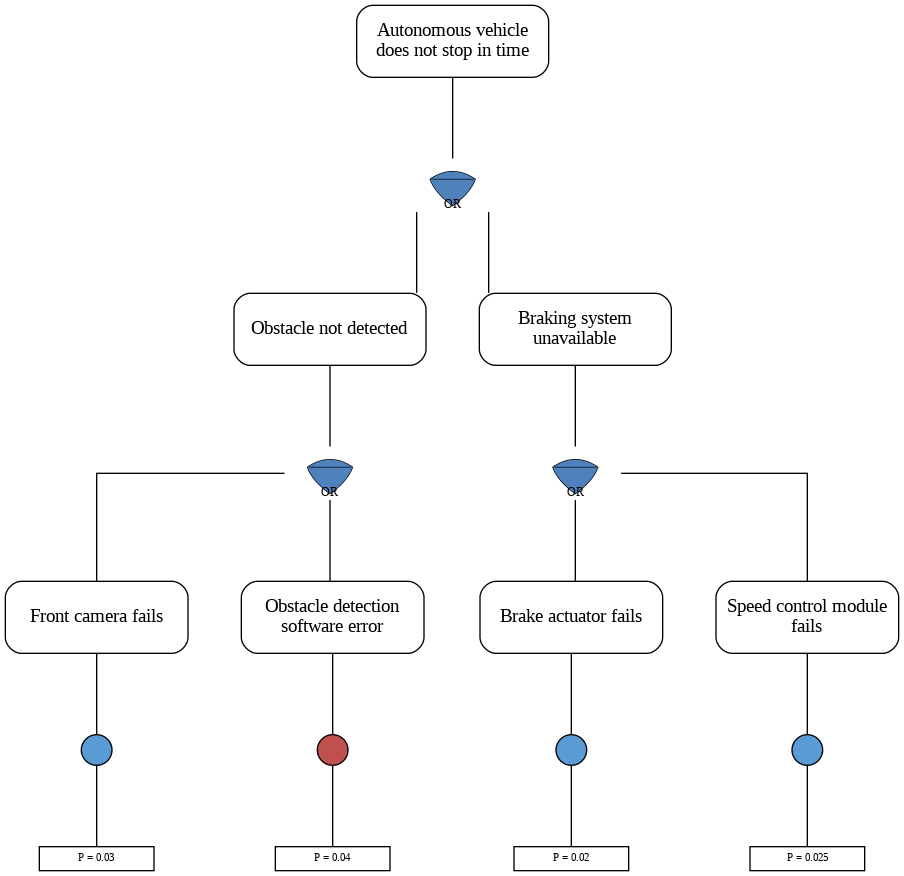

Diagram saved as: simple_autonomous_vehicle_fault_tree.png
MOCUS and MICSUP match: True


,Node,Type,Probability
0,Brake actuator fails,BASIC,0.02
1,Front camera fails,BASIC,0.03
2,Obstacle detection software error,BASIC,0.04
3,Speed control module fails,BASIC,0.025
4,Autonomous vehicle does not stop in time,OR,0.11
5,Braking system unavailable,OR,0.044
6,Obstacle not detected,OR,0.069


,Gate,Gate Type,Children,Child Probabilities,Gate Probability
0,Autonomous vehicle does not stop in time,OR,Obstacle not detected | Braking system unavail...,0.069 | 0.044,0.11
1,Obstacle not detected,OR,Front camera fails | Obstacle detection softwa...,0.03 | 0.04,0.069
2,Braking system unavailable,OR,Brake actuator fails | Speed control module fails,0.02 | 0.025,0.044


,ID,Cut Set,Order
0,1,Brake actuator fails,1
1,2,Front camera fails,1
2,3,Obstacle detection software error,1
3,4,Speed control module fails,1


,ID,Cut Set,Order
0,1,Brake actuator fails,1
1,2,Front camera fails,1
2,3,Obstacle detection software error,1
3,4,Speed control module fails,1


In [5]:
# Build the sample autonomous vehicle fault tree
vehicle_tree = build_simple_autonomous_vehicle_case()

# Run full analysis and generate output diagram
results = vehicle_tree.run_dashboard(image_path="simple_autonomous_vehicle_fault_tree")

# Display probability table
display(results["probability_table"])

# Display gate analysis table
display(results["gate_analysis_table"])

# Display minimal cut sets from MOCUS
display(results["mocus_minimal_cut_sets"])

# Display minimal cut sets from MICSUP
display(results["micsup_minimal_cut_sets"])